# Examen Corto 1

- Mathew Alexander Cordero Aquino - 22982
- Gustavo Adolfo Cruz Bardales - 22779

[Repositorio](https://github.com/donmatthiuz/VIC/tree/Corto1)

# Task 1 - Análisis

Imagine que está diseñando el primer bloque de una arquitectura convolucional para procesar imágenes
satelitales multiespectrales de entrada con dimensiones 𝑊 = 256, 𝐻 = 256, 𝐶 = 4 (RGB + Infrarrojo). Tiene
dos opciones de diseño para este primer bloque, asumiendo que ambas buscan extraer 64 canales de salida
(𝐶𝑜𝑢𝑡 = 64):

- Opcion A (Estilo AlexNet): Una capa convolucional con filtros de 7 × 7, stride de 2 y padding de 0.
- Opción B (Estilo VGG): Tres capas convolucionales secuenciales con filtros de 3 × 3, stride de 1 y
padding de 1, seguidas de una capa de Max-Pooling de 2 × 2 (stride 2).

## 1. 

Dado que tenemos $$O = \frac{W-K+2P}{S} +1$$

Para las opciones el calculo seria el siguiente:

- Opcion A: $$O=\frac{256-7+2*0}{2} +1$$ $$O=\frac{249}{2} +1$$ $$O=124.5 +1$$ $$O=125.5$$ $$O=125$$

- Opcion B: $$O=\frac{256-3+2*1}{1} +1$$ $$O=\frac{253+2}{1} +1$$ $$O=255 +1$$ $$O=256$$ Esto si lo ejecutamos 3 veces da lo mismo asi que nos saltamos a la max-pooling. $$O=\frac{256-2+2*1}{2} + 1$$ $$O=\frac{254}{2} + 1$$ $$O=127 + 1$$ $$O=128$$


## 2. 

Calcula matemáticamente cuántos parámetros entrenables (pesos) requiere la Opción A vs. las
capas convolucionales de la Opción B. Basado en la teoría del Campo Receptivo, justifica por qué la
industria estandarizó la Opción B.

Para ello usamos la formula para calcular los parametros

$$P = (F×F×C_{in}​)×C_{out}​+C_{out}​$$

- F = tamaño del filtro
- C_{in} = Canales de entrada
- C_{out} = Canales de salida

- Opcion A (Estilo AlexNet): $$P = (7×7×4​)×64​+64$$ $$P = 12,608$$

- Opcion B (Estilo VGG): 

Primera convolusion $$P = (3×3×4​)×64​+64$$ $$P = 2,368$$

Segunda convolusion $$P = (3×3×64​)×64​+64$$ $$P = 36,928$$


Tercera convolusion $$P = (3×3×64​)×64​+64$$ $$P = 36,928$$

Total $$P =  36,928 + 2,368 + 36,928 $$ $$P = 76,224$$


### Justificacion

Se uso la opcion B en la industria debido a que como vimos tiene muchos mas parametros. Segun la definicion de campo receptivo se ve como la parte de la imagen de entrada que influye en la activación de una neurona en una capa.

Por ende podemos decir que el campo receptivo en cada capa convolucional es el tamaño del filtro que se le aplica. Lo cual le sirve a la red detectar bordes, formas y objetos, dada su jerarquia primero los bordes, luego las formas , luego objetos y de ultimo conceptos. 

Entonces al haber mas capas generan mas parametros que a su vez hace que la red neuronal tenga una mayor capacidad de aprendizaje y representación de características. Esto permite que la red extraiga patrones más complejos entender mas que esta viendo que solo representarlo.


# Task 2 – Criterio

Una cooperativa agrícola en Guatemala los ha contratado para automatizar la detección de enfermedades
en cultivos de mango. El gerente de TI de la cooperativa sugiere usar algoritmos tradicionales (SIFT y HOG
combinados con un SVM) porque "son más ligeros y no requieren GPUs". Ustedes, como directores del
proyecto de IA, proponen utilizar un enfoque basado en Deep Learning usando Transfer Learning con una
arquitectura clásica. Respondan:

- **Redacte una justificación técnica (máximo 2 párrafos) dirigida al gerente de TI explicando por qué
SIFT/HOG fallarían en un entorno agrícola real frente a variaciones de luz, ángulos y oclusiones, y
cómo los "Mapas de Características" de una red profunda solucionan la variabilidad semántica.**

Se debe de usar una arquitectura clasica debido a que un enfoque clasico si bien es bueno para entornos estables sin variabilidad para entornos complejos donde es requerido el calculo de gradientes y descriptores directamente sobre el pixel no lo es asi. 
Lo que hacen este tipo de arquitecturas es entender y comprender no la ubicación de cada pixel. Al realizar multiples convoluciones y poolings lo que se va haciendo cada vez es añadiendo funciones de activación no lineales, lo que introduce mas linealidad y hace el modelo mas generales.

Al hacer esto ultimo los feature maps en donde se va respetando la representacion jerarquia visual, ya que en las primeras capas se ven bordes, en las siguientes estructuras semanticas, en las siguientes objetos y en las ultimas todo el contexto de nuestra imagen original. Logrando asi que si ve una imagen que tiene sombras e iluminación diferente como lo es una maceta, al pasarlo por estas redes entiende que es el mismo objeto.



- **Si tuviera que elegir estrictamente entre usar la arquitectura AlexNet o VGG-16 para extraer
características de las hojas, ¿cuál elegiría y por qué? Justifique su respuesta basándote en la
modularidad, la no-linealidad (ReLU) y la capacidad de abstracción de capas profundas.**


Yo elegiria VGG-16, lo que pasa con VGG es que es un modelo que introduce muchos mas pesos, aqui en vez de hacer capas enormes convolucionales , se hacen pequeñas pero varias, lo que hace que existan mas funciones de activación, gracias a esta capacidad de abstracción, VGG suele extraer características más robustas para tareas de visión por computadora, como la identificación de hojas en diferentes condiciones.


Esto sirve un monton ya que el modelo entiende y aprende no solo repite y memoriza, lo cual hace que mientras mas capas le coloquemos lo hagan mas general y asi abstraiga la idea general del objeto en vez de copiarlo. 


Tambien VGG es util mas que Alex porque aqui podemos cambiar a gusto los filtros y tambien la cantidad que querramos colocar, haciendola practica para ir haciendo pruebas y optimizandolo,  en cambio Alex fue un diseño de prueba y error hasta encontrar una combinación correcta. Lo que provoca que sea dificil cambiar para optimizarlo o hacer pruebas.


# Task 3

In [20]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Este notebook se trabajo utilizando Kaggle en una configuración multi gpu, para probar que si servía puse
# algunos prints como verificación que si funcionaban ambas gpus T4
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs disponibles: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs disponibles: 2


In [21]:
DATA_DIR = '/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset'
BATCH_SIZE = 32 * strategy.num_replicas_in_sync
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (tf.keras.applications.vgg16.preprocess_input(x), y), 
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.map(
    lambda x, y: (tf.keras.applications.vgg16.preprocess_input(x), y), 
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4000 files belonging to 8 classes.
Using 3200 files for training.
Found 4000 files belonging to 8 classes.
Using 800 files for validation.


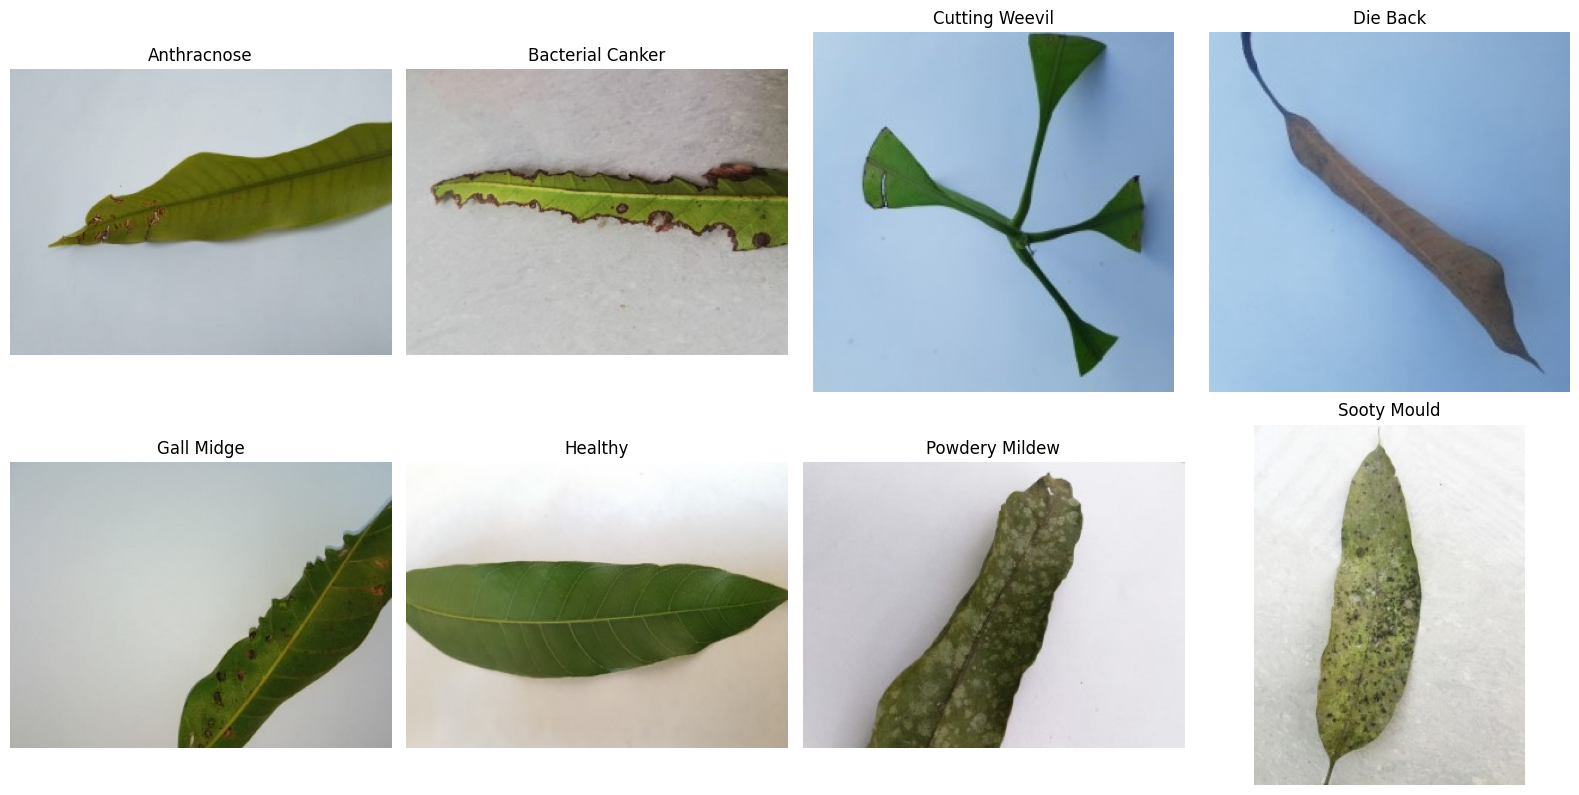

In [22]:
# Agregue este chunk para poder ver las clases de imagenes que existen, debido a que 
# el modelo no logro identificar correctamente en 2 clases (aunque fue un error minimo de 6 instancias)
plt.figure(figsize=(16, 8))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    first_image_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, first_image_name)
    
    img = plt.imread(img_path)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# este scope me permite, con la configuración que se declaro en el primer chunk 
# "strategy = tf.distribute.MirroredStrategy()" dividir los datos en las 2 gpus, pero
# unifica el aprendizaje
with strategy.scope():
    base_model = tf.keras.applications.VGG16(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

In [24]:
# training y backpropagation
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 319ms/step - accuracy: 0.6809 - loss: 4.5092 - val_accuracy: 0.9688 - val_loss: 0.1436
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step - accuracy: 0.9242 - loss: 0.3974 - val_accuracy: 0.9900 - val_loss: 0.0525
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.9436 - loss: 0.2515 - val_accuracy: 0.9875 - val_loss: 0.0965
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 319ms/step - accuracy: 0.9518 - loss: 0.2404 - val_accuracy: 0.9875 - val_loss: 0.0950
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 317ms/step - accuracy: 0.9558 - loss: 0.2205 - val_accuracy: 0.9887 - val_loss: 0.0571
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step - accuracy: 0.9532 - loss: 0.2113 - val_accuracy: 0.9937 - val_loss: 0.0565
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.9920 - loss: 0.0361
Accuracy global: 0.9900


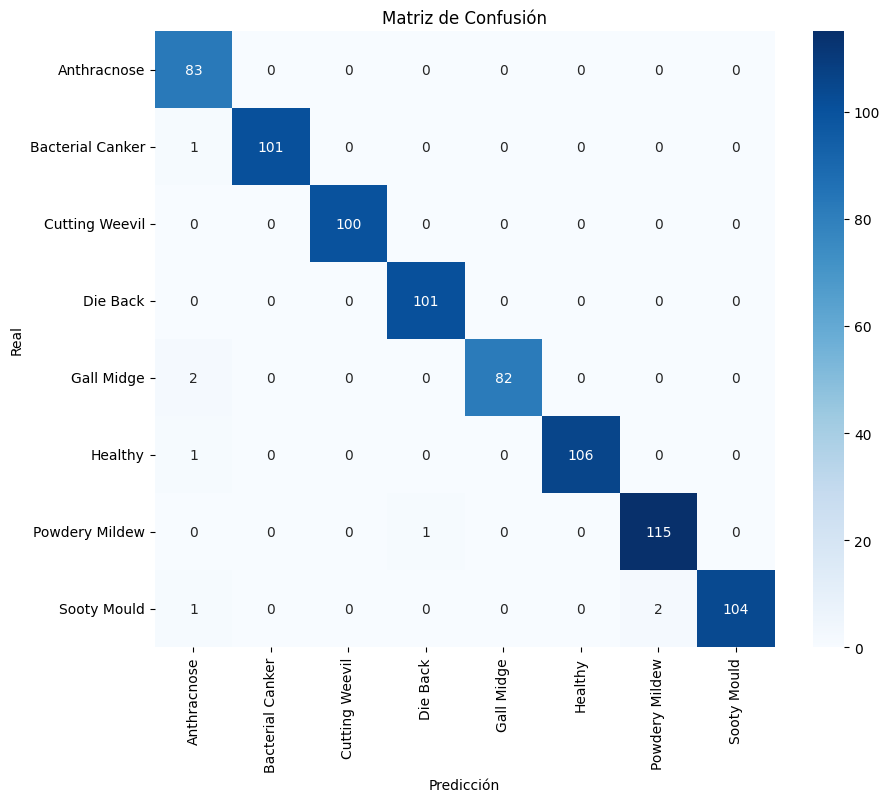

In [25]:
# evaluaci'on del modelo
val_loss, val_acc = model.evaluate(val_ds)
print(f"Accuracy global: {val_acc:.4f}")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

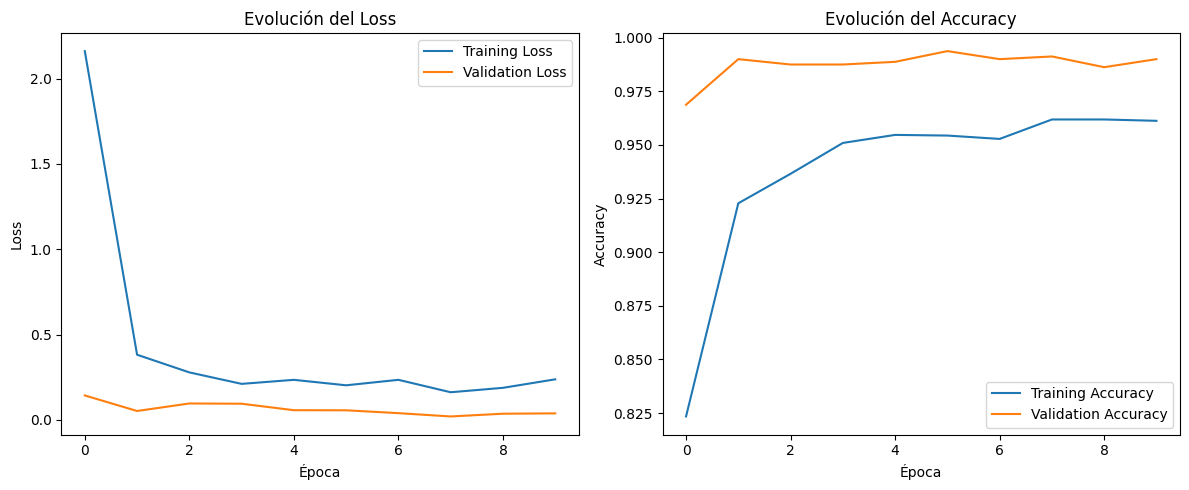

In [26]:
# Tambien coloque los siguientes graficos para apoyarme en el reporte de resultados, especialmente
# para concluir si existe o no overfitting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución del Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolución del Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Reporte de Evaluación

## Precisión global 
El modelo alcanzó una precisión global del 99% sobre el conjunto de validación al finalizar el entrenamiento.

## Matriz de Confusión
El gráfico refleja un excelente rendimiento en la clasificación de las hojas. La gran mayoría de las enfermedades como Bacterial Canker, Cutting Weevil, Anthracnose y Die Back fueron identificadas con una precisión perfecta. Las confusiones que tiene el modelo realmente son mínimas, generalmente 1 error o 2. 

Luego de realizar otras pruebas, se eliminó un error en la confusión del modelo para identificar Powdery Mildew y Sooty Mould (antes daba hasta 6 errores para clasificar entre esas 2 clases) debido a que son visualmente parecidas, ya que ambas son manchas sobre las hojas.

## Conclusión sobre Sobreajuste (Overfitting) 
Al observar la evolución del loss y del accuracy, se concluye contundentemente que no existe sobreajuste. Como se puede ver en las gráficas, muestran un comportamiento particular donde la curva de validación se mantiene con mejores métricas, mayor accuracy y menor loss, que la curva de entrenamiento durante todas las épocas. Esto evidencia el dropout utilizado y su buen funcionamiento en el modelo, el dropout es de 0.5, esto quiere decir que durante el entrenamiento, el modelo es penalizado constantemente al apagar aleatoriamente la mitad de sus neuronas, lo que deprime su accuracy y eleva su loss para forzarlo a aprender características robustas. Siempre tomando en cuenta que al evaluar en el conjunto de validación, el dropout sí se desactiva.